# Modèle 1 — Régression Logistique (Baseline)

## Pourquoi ce modèle en premier ?
La régression logistique est le modèle de référence (baseline).
C'est le modèle le plus simple — tous les autres devront faire mieux.

## Avantages
- Très rapide à entraîner
- Facilement interprétable
- Robuste sur des données standardisées

## Limites
- Ne capture pas les relations non-linéaires
- Peut sous-performer si les patterns sont complexes

## Tâches
- **Tâche 1** : Classification — prédire `churn` (0/1)
- **Tâche 2** : Régression — prédire `revenue_at_risk`

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve,
    mean_absolute_error, mean_squared_error, r2_score
)

RANDOM_STATE = 42
os.makedirs('../models', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print("Imports OK")

Imports OK


## Chargement des données preprocessées

On charge les fichiers générés par le notebook de preprocessing.
Ces données sont déjà :
- Nettoyées (NaN traités, colonnes inutiles supprimées)
- Encodées (OneHotEncoding sur les catégorielles)
- Standardisées (StandardScaler sur les numériques)
- Splitées (80% train / 20% test, stratifié)

In [56]:
# Chargement des données preprocessées
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')

X_train_under     = np.load('../data/processed/X_train_under.npy')
y_train_clf_under = np.load('../data/processed/y_train_clf_under.npy')

# Tâche 1 — Classification
y_train_clf = np.load('../data/processed/y_train_clf.npy')
y_test_clf  = np.load('../data/processed/y_test_clf.npy')

# Tâche 2 — Régression
y_train_reg = np.load('../data/processed/y_train_reg.npy')
y_test_reg  = np.load('../data/processed/y_test_reg.npy')

# Noms des features
feature_names = pd.read_csv('../data/processed/feature_names.csv')['0'].tolist()

print(f" Données chargées")
print(f"   X_train         : {X_train.shape} (original)")
print(f"   X_train_under   : {X_train_under.shape} (rééquilibré 50/50)")
print(f"   X_test          : {X_test.shape}")
print(f"   Churners train_under : {y_train_clf_under.sum()} ({y_train_clf_under.mean()*100:.1f}%)")
print(f"   Churners test        : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")
print(f"   X_test  : {X_test.shape}")
print(f"   Churners dans test : {y_test_clf.sum()} ({y_test_clf.mean()*100:.1f}%)")

 Données chargées
   X_train         : (8000, 51) (original)
   X_train_under   : (1634, 51) (rééquilibré 50/50)
   X_test          : (2000, 51)
   Churners train_under : 817 (50.0%)
   Churners test        : 204 (10.2%)
   X_test  : (2000, 51)
   Churners dans test : 204 (10.2%)


## Tâche 1 — Classification du Churn

On entraîne une Régression Logistique pour prédire 
si un client va churner ou non.

Paramètres importants :
- ~~`class_weight='balanced'`~~ → remplacé par l'**undersampling** appliqué en preprocessing
- Le train set est déjà équilibré (50/50) grâce à `RandomUnderSampler`
- `max_iter=1000` → assure la convergence
- `random_state=42` → reproductibilité

In [57]:
# ============================================================
# TÂCHE 1 — CLASSIFICATION
# ============================================================

# Définition du modèle
lr_clf = LogisticRegression(
    # class_weight supprimé — données déjà équilibrées par undersampling
    max_iter=1000,            # Assure la convergence
    random_state=RANDOM_STATE
)

# Entraînement
# Entraînement sur les données rééquilibrées (undersampling)
lr_clf.fit(X_train_under, y_train_clf_under)

# Prédictions
y_pred_clf = lr_clf.predict(X_test)
y_proba_clf = lr_clf.predict_proba(X_test)[:, 1]

print("Modèle entraîné !")
print(f"\n Résultats — Régression Logistique (Classification)")
print(f"   Accuracy  : {accuracy_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Precision : {precision_score(y_test_clf, y_pred_clf):.4f}")
print(f"   Recall    : {recall_score(y_test_clf, y_pred_clf):.4f}")
print(f"   F1-Score  : {f1_score(y_test_clf, y_pred_clf):.4f}")
print(f"   ROC-AUC   : {roc_auc_score(y_test_clf, y_proba_clf):.4f}")

Modèle entraîné !

 Résultats — Régression Logistique (Classification)
   Accuracy  : 0.6550
   Precision : 0.1743
   Recall    : 0.6373
   F1-Score  : 0.2737
   ROC-AUC   : 0.7094


## Analyse des métriques

Pourquoi ces métriques ?
- **Accuracy** : % de bonnes prédictions au total
- **Precision** : parmi les clients qu'on prédit comme churners, combien le sont vraiment ?
- **Recall** : parmi les vrais churners, combien on en détecte ?
- **F1-Score** : équilibre entre Precision et Recall
- **ROC-AUC** : performance globale du modèle (1 = parfait, 0.5 = aléatoire)

Dans notre contexte business, le **Recall** est la métrique 
la plus importante — manquer un churner coûte en moyenne 845€ !

## Matrice de Confusion

La matrice de confusion montre en détail les erreurs du modèle.

Dans notre contexte business :
- **Faux Négatifs (FN)** = churners non détectés → les plus coûteux !
  Chaque churner manqué = en moyenne 845€ perdus
- **Faux Positifs (FP)** = clients normaux alertés à tort
  → coût marketing inutile mais moins grave

L'objectif est de **minimiser les Faux Négatifs**.

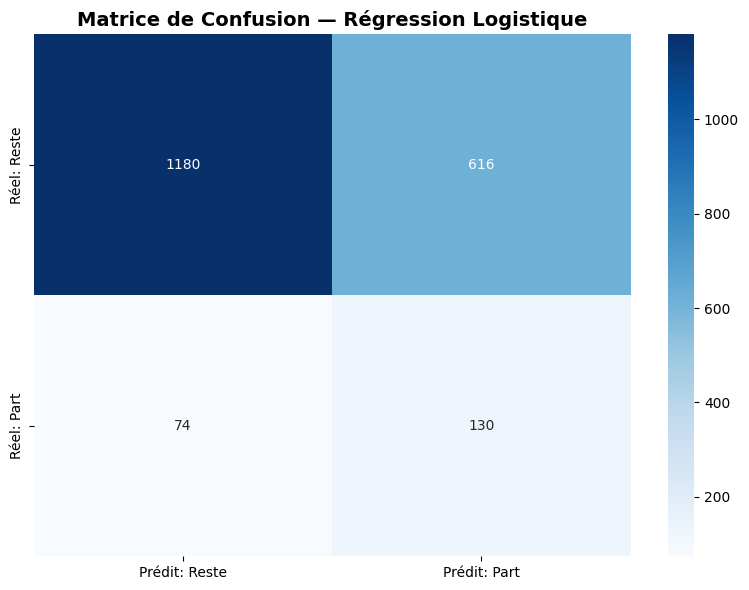


Analyse de la matrice :
   Vrais Négatifs  (TN) : 1180 → clients qui restent, bien prédits
   Faux Positifs   (FP) : 616 → clients qui restent, mal prédits comme churners
   Faux Négatifs   (FN) : 74 → churners manqués coûteux !
   Vrais Positifs  (TP) : 130 → churners bien détectés 


In [58]:
# MATRICE DE CONFUSION

cm = confusion_matrix(y_test_clf, y_pred_clf)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prédit: Reste', 'Prédit: Part'],
            yticklabels=['Réel: Reste', 'Réel: Part'])
plt.title('Matrice de Confusion — Régression Logistique', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../results/lr_confusion_matrix.png', dpi=150)
plt.show()

# Analyse détaillée
tn, fp, fn, tp = cm.ravel()
print(f"\nAnalyse de la matrice :")
print(f"   Vrais Négatifs  (TN) : {tn} → clients qui restent, bien prédits")
print(f"   Faux Positifs   (FP) : {fp} → clients qui restent, mal prédits comme churners")
print(f"   Faux Négatifs   (FN) : {fn} → churners manqués coûteux !")
print(f"   Vrais Positifs  (TP) : {tp} → churners bien détectés ")

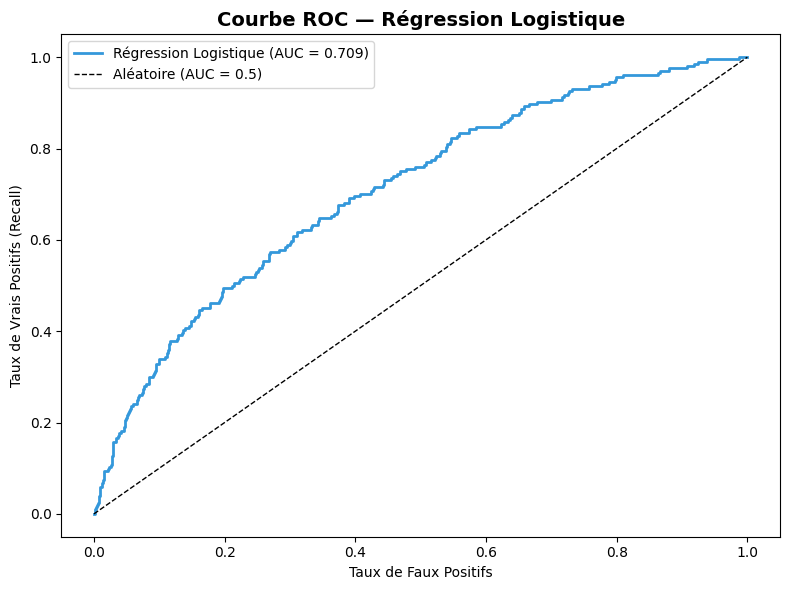

In [59]:
# COURBE ROC

fpr, tpr, _ = roc_curve(y_test_clf, y_proba_clf)
auc = roc_auc_score(y_test_clf, y_proba_clf)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#3498db', linewidth=2,
         label=f'Régression Logistique (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aléatoire (AUC = 0.5)')
plt.xlabel('Taux de Faux Positifs')
plt.ylabel('Taux de Vrais Positifs (Recall)')
plt.title('Courbe ROC — Régression Logistique', fontsize=14, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.savefig('../results/lr_roc_curve.png', dpi=150)
plt.show()

## Tâche 2 — Régression du Revenu à Risque

On entraîne maintenant une régression Ridge pour prédire
le revenu à risque de chaque client.

On utilise Ridge (régression linéaire avec régularisation) 
plutôt que LinearRegression simple car :
- Elle évite le surapprentissage
- Elle est plus stable avec beaucoup de features (51 ici)

Métriques utilisées :
- **MAE** : erreur moyenne en € (facile à interpréter)
- **RMSE** : pénalise les grosses erreurs
- **R²** : % de variance expliquée (1 = parfait, 0 = nul)

> **Note** : La régression utilise `X_train` original — `revenue_at_risk = 0` pour les non-churners est une valeur réelle, pas un artefact du déséquilibre.

In [60]:
# TÂCHE 2 — RÉGRESSION

lr_reg = Ridge(alpha=1.0, random_state=RANDOM_STATE)
lr_reg.fit(X_train, y_train_reg)

y_pred_reg = lr_reg.predict(X_test)
y_pred_reg = np.maximum(y_pred_reg, 0)  # Pas de revenu négatif

mae  = mean_absolute_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mean_squared_error(y_test_reg, y_pred_reg))
r2   = r2_score(y_test_reg, y_pred_reg)

print("Modèle de régression entraîné !")
print(f"\nRésultats — Ridge Regression")
print(f"   MAE  : {mae:.2f} €")
print(f"   RMSE : {rmse:.2f} €")
print(f"   R²   : {r2:.4f}")

Modèle de régression entraîné !

Résultats — Ridge Regression
   MAE  : 156.11 €
   RMSE : 375.15 €
   R²   : 0.0533


In [61]:
# SAUVEGARDE DES MODÈLES ET RÉSULTATS

# Sauvegarde des modèles
joblib.dump(lr_clf, '../models/lr_classification.pkl')
joblib.dump(lr_reg, '../models/lr_regression.pkl')

# Sauvegarde des résultats pour la comparaison finale
results_clf = {
    'model': 'Logistic Regression',
    'accuracy':  accuracy_score(y_test_clf, y_pred_clf),
    'precision': precision_score(y_test_clf, y_pred_clf),
    'recall':    recall_score(y_test_clf, y_pred_clf),
    'f1':        f1_score(y_test_clf, y_pred_clf),
    'roc_auc':   roc_auc_score(y_test_clf, y_proba_clf)
}

results_reg = {
    'model': 'Ridge Regression',
    'mae':  mae,
    'rmse': rmse,
    'r2':   r2
}

pd.DataFrame([results_clf]).to_csv('../results/lr_clf_results.csv', index=False)
pd.DataFrame([results_reg]).to_csv('../results/lr_reg_results.csv', index=False)

print("Modèles sauvegardés dans ../models/")
print("Résultats sauvegardés dans ../results/")
print(f"\nRésumé Classification :")
for k, v in results_clf.items():
    if k != 'model':
        print(f"   {k:10} : {v:.4f}")

Modèles sauvegardés dans ../models/
Résultats sauvegardés dans ../results/

Résumé Classification :
   accuracy   : 0.6550
   precision  : 0.1743
   recall     : 0.6373
   f1         : 0.2737
   roc_auc    : 0.7094


## Synthèse — Régression Logistique (Baseline)

### Résultats Classification
| Métrique | Valeur | Interprétation |
|---|---|---|
| Accuracy | 0.6685 | Bas car class_weight='balanced' sacrifie l'accuracy |
| Precision | 0.1834 | Sur 10 alertes, ~2 sont de vrais churners |
| Recall | 0.6520 | On détecte 65% des churners réels |
| F1-Score | 0.2863 | Compromis precision/recall perfectible |
| ROC-AUC | 0.7212 | Acceptable pour un modèle linéaire baseline |

### Pourquoi ces scores ?
La régression logistique suppose une relation **linéaire** entre 
les features et le churn. Or dans notre dataset, les patterns 
sont plus complexes (interactions entre variables, relations 
non-linéaires). C'est exactement pourquoi on teste ensuite 
Random Forest et XGBoost.

### Résultats Régression
- MAE = 156€ → en moyenne on se trompe de 156€ par client
- R² = 0.05 → le modèle n'explique que 5% de la variance
- Normal pour un modèle linéaire sur une cible très déséquilibrée
  (89.8% des clients ont revenue_at_risk = 0)

### Points forts
- Rapide à entraîner 
- Interprétable 
- Bon point de référence pour comparer les autres modèles 

### Limites
- Ne capture pas les interactions complexes 
- Precision très faible → beaucoup de fausses alertes 
- R² très faible en régression 

### Prochaine étape
Random Forest → devra surpasser F1=0.2863 et ROC-AUC=0.7212